# Notebook 1 — Data Preparation & Elevation Enrichment

**Progetto:** *ML per l'energia e il contesto di guida* sul Vehicle Energy Dataset (VED) —
applicazione a un assistente di guida / cruise control adattivo.

**Scopo di questo notebook:**
1. Caricare i file parquet del dataset VED e consolidarli in un unico DataFrame
2. Esplorare la struttura, fare sanity check e gestire outlier
3. Arricchire i dati con l'altitudine (Open-Meteo Elevation API)
4. Calcolare la pendenza (slope) e l'accelerazione lungo ogni trip
5. Salvare un parquet "enriched" pronto per i notebook ML successivi

**Output finale:** `ved_enriched.parquet` — dataset consolidato + elevation + slope + accel, usato
da tutti i notebook successivi.

> Da eseguire **una volta sola**. I successivi caricano direttamente l'output.
>
> *Nota di inquadramento:* l'altitudine/pendenza qui calcolata era pensata come feature centrale
> ("ACC che sfrutta l'orografia"), ma si rivelera' un **segnale debole** (Ann Arbor piatta +
> quantizzazione a ~111 m). Il progetto e' stato reinquadrato sul profilo di velocita' anticipato;
> la pendenza resta come *limite del dato documentato*. Vedi
> `project context/RELAZIONE_PROGETTO.md`.

## 1. Setup e import

In [1]:
import os
import glob
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Usa il trust store nativo del SO (Windows/macOS) per la verifica SSL.
# Necessario dietro proxy/antivirus aziendali che intercettano HTTPS con una CA
# non presente nel bundle di certifi (altrimenti le chiamate a Open-Meteo falliscono
# con CERTIFICATE_VERIFY_FAILED).
try:
    import truststore
    truststore.inject_into_ssl()
    print("truststore attivo (verifica SSL via trust store del SO)")
except ImportError:
    print("truststore non installato: se le chiamate API falliscono per SSL, esegui 'pip install truststore'")

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')

# Tutti i parquet del VED vanno in questa cartella (nessuna distinzione di fase).
DATA_DIR = Path("./content")

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup OK")

truststore attivo (verifica SSL via trust store del SO)
Setup OK


## 2. Caricamento dei file parquet

Carichiamo **tutti** i file parquet presenti in `content/` (ricorsivamente) e li concateniamo in un singolo DataFrame.

Il dataset VED su Kaggle è distribuito in più file settimanali con schema identico, quindi la concatenazione è diretta. Non distinguiamo l'origine temporale (Phase 1 / Phase 2): è un metadato che non usiamo né nel modello supervised né nel clustering, e lo split temporale del Notebook 2 si basa comunque su `Datetime`.

In [2]:
files = sorted(glob.glob(str(DATA_DIR / "**" / "*.parquet"), recursive=True))
print(f"Trovati {len(files)} file parquet in {DATA_DIR}/")
if not files:
    raise FileNotFoundError(
        f"Nessun parquet in {DATA_DIR.resolve()}. "
        "Metti i file VED *.parquet dentro la cartella content/."
    )

df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)

print(f"\nDataset consolidato: {df.shape[0]:,} righe × {df.shape[1]} colonne")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Trovati 54 file parquet in content/

Dataset consolidato: 18,258,138 righe × 18 colonne
Memoria: 1.59 GB


## 3. Ispezione iniziale

Controllo veloce di tipi, NaN, range temporale, dimensione della flotta.

In [3]:
print("=== DTYPE ===")
print(df.dtypes)

print("\n=== NaN per colonna ===")
print(df.isna().sum())

print("\n=== Range temporale ===")
print(f"Da: {df['Datetime'].min()}")
print(f"A:  {df['Datetime'].max()}")
print(f"Durata: {(df['Datetime'].max() - df['Datetime'].min()).days} giorni")

print("\n=== Flotta ===")
print(f"Veicoli unici:     {df['VehId'].nunique()}")
print(f"Trip unici:        {df.groupby(['VehId','Trip']).ngroups:,}")
print(f"EngineType:")
print(df['EngineType'].value_counts())

=== DTYPE ===
VehId                                       int32
Trip                                        int32
Timestampms                                 int32
Latitude_deg                              float32
Longitude_deg                             float32
Vehicle_Speed_km_per_h                    float32
MAF_g_per_sec                             float32
Engine_RPM_RPM                            float32
Absolute_Load_pct                         float32
OAT_DegC                                  float32
Short_Term_Fuel_Trim_Bank_1_pct           float32
Short_Term_Fuel_Trim_Bank_2_pct           float32
Long_Term_Fuel_Trim_Bank_1_pct            float32
Long_Term_Fuel_Trim_Bank_2_pct            float32
Datetime                           datetime64[ns]
EngineType                                    str
Generalized_Weight                        float64
log_MAF                                   float32
dtype: object

=== NaN per colonna ===
VehId                              0
Trip      

## 4. EDA — Distribuzioni e controllo outlier

Visualizziamo la distribuzione delle feature principali per identificare outlier e capire il dataset. Particolare attenzione a `Absolute_Load_pct`, che in analisi preliminare aveva mostrato valori >500% (errori di sensore).

In [4]:
feats_numeriche = [
    'Vehicle_Speed_km_per_h', 'MAF_g_per_sec', 'Engine_RPM_RPM',
    'Absolute_Load_pct', 'OAT_DegC', 'Generalized_Weight'
]

df[feats_numeriche].describe()

,Vehicle_Speed_km_per_h,MAF_g_per_sec,Engine_RPM_RPM,Absolute_Load_pct,OAT_DegC,Generalized_Weight
count,1.825814e+07,1.825814e+07,1.825814e+07,1.825814e+07,1.825814e+07,1.825814e+07
mean,4.060867e+01,9.674236e+00,1.176176e+03,2.984027e+01,1.103543e+01,3.377251e+03
std,2.690561e+01,1.031936e+01,7.480685e+02,6.786961e+01,1.265736e+01,5.946777e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.000000e+01,2.500000e+03
25%,2.000000e+01,2.700000e+00,7.150000e+02,1.490196e+01,1.176546e+00,3.000000e+03
50%,4.300000e+01,5.400000e+00,1.246000e+03,2.627451e+01,9.000000e+00,3.500000e+03
75%,5.800000e+01,1.447000e+01,1.646000e+03,4.470588e+01,2.200000e+01,3.500000e+03
max,1.730000e+02,2.593100e+02,6.605000e+03,2.246353e+04,6.000000e+01,6.000000e+03


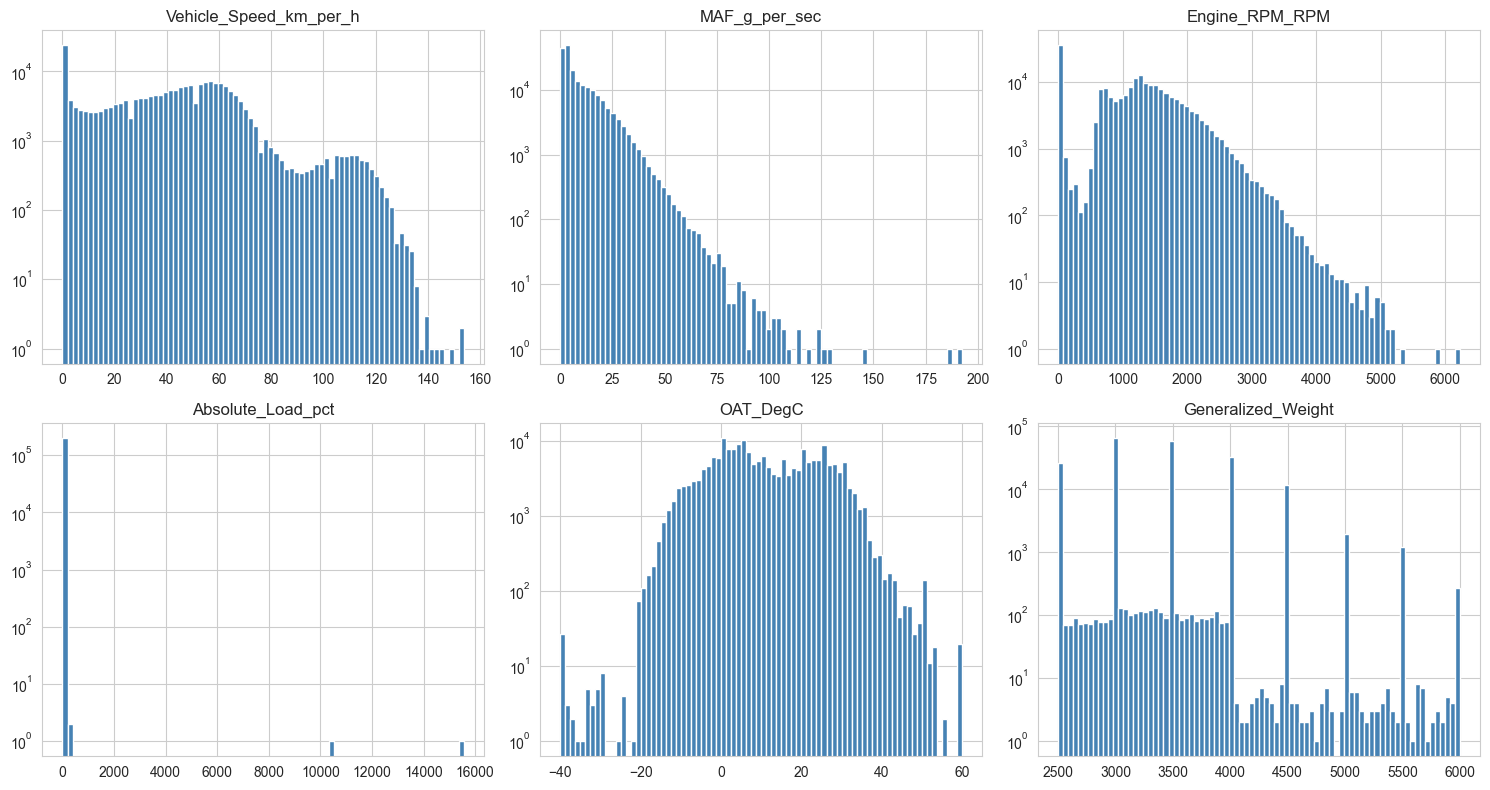

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feats_numeriche):
    # campioniamo per velocizzare i plot
    sample = df[col].sample(n=min(200_000, len(df)), random_state=42)
    sample.hist(bins=80, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_yscale('log')
plt.tight_layout()
plt.show()

### 4.1 Gestione outlier su Absolute_Load_pct

Tecnicamente `Absolute Load` può eccedere 100% (è una percentuale del flusso d'aria massimo a sea-level, in condizioni di turbo / discesa può superare 100). Ma valori > 200% sono quasi certamente errori di sensore: li tronchiamo.

Per Vehicle_Speed e RPM applichiamo soglie ragionevoli per veicoli civili. Documenta sempre queste scelte: un docente apprezza il pensiero critico sul dato reale.

In [6]:
before = len(df)

# Maschere di validità
mask = (
    (df['Absolute_Load_pct'].between(0, 200)) &
    (df['Vehicle_Speed_km_per_h'].between(0, 200)) &
    (df['Engine_RPM_RPM'].between(0, 8000)) &
    (df['MAF_g_per_sec'].between(0, 300))
)

df = df[mask].copy()
after = len(df)
print(f"Rimosse {before - after:,} righe ({(before-after)/before*100:.3f}%)")
print(f"Dataset ora: {after:,} righe")

Rimosse 481 righe (0.003%)
Dataset ora: 18,257,657 righe


### 4.2 Esplorazione spaziale

Confermiamo che tutto il dataset copre l'area di Ann Arbor (MI), e visualizziamo la densità dei punti.

Lat: [42.2203, 42.3258]
Lon: [-83.8043, -83.6740]


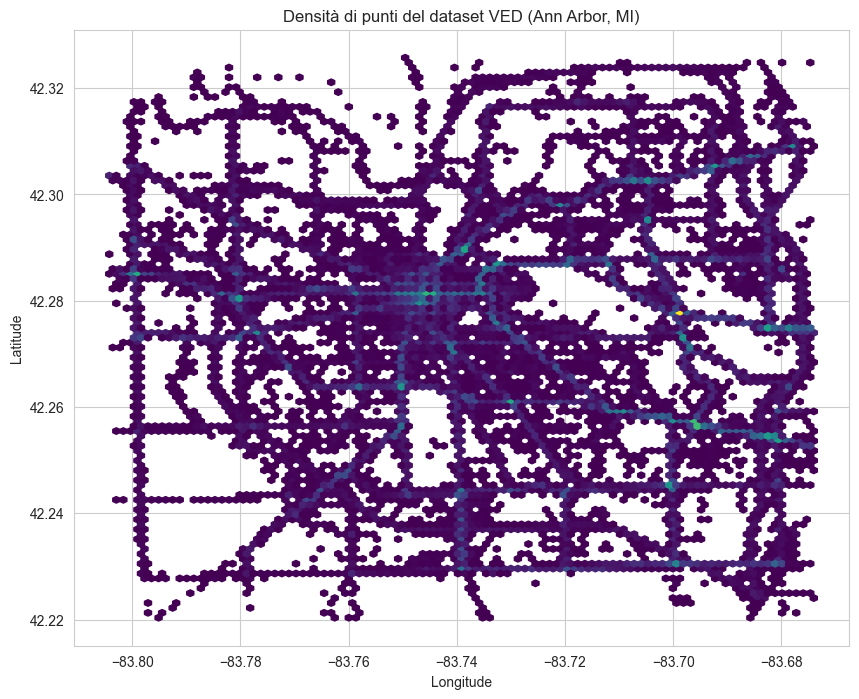

In [7]:
print(f"Lat: [{df['Latitude_deg'].min():.4f}, {df['Latitude_deg'].max():.4f}]")
print(f"Lon: [{df['Longitude_deg'].min():.4f}, {df['Longitude_deg'].max():.4f}]")

# Heatmap della densità di campionamento (campione per velocità di rendering)
sample = df.sample(n=200_000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 8))
ax.hexbin(sample['Longitude_deg'], sample['Latitude_deg'], gridsize=100, cmap='viridis', mincnt=1)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Densità di punti del dataset VED (Ann Arbor, MI)')
plt.show()

## 5. Filtro su movimento valido

Molte righe corrispondono a veicolo fermo (Speed=0) o motore acceso ma fermo: utili per anomaly detection ma rumorose per il nostro task di predizione del consumo dinamico. Manteniamo solo righe con velocità > 0 oppure RPM > 0 (motore in funzione).

In [8]:
before = len(df)
df = df[(df['Vehicle_Speed_km_per_h'] > 0) | (df['Engine_RPM_RPM'] > 100)].copy()
print(f"Dopo filtro movimento: {len(df):,} righe (rimosse {before-len(df):,})")

Dopo filtro movimento: 17,922,869 righe (rimosse 334,788)


## 6. Enrichment con Elevation API

Il dataset **non contiene l'altitudine**: la dobbiamo derivare. Usiamo **Open-Meteo Elevation API** (gratuita, no API key, basata su SRTM).

**Strategia di dedup spaziale:** invece di chiamare l'API per ogni riga (~18M chiamate, impossibile), arrotondiamo le coordinate e chiediamo l'elevation solo per i punti unici.

**Quanti decimali?** La risoluzione conta. SRTM (la sorgente dietro Open-Meteo) ha una risoluzione di **~30 m**: interrogare punti più vicini di così è spreco puro, perché ricadono nella stessa cella SRTM e restituiscono la stessa quota. Sui nostri dati:
- `round(4)` (~11 m) → ~282k punti unici → ~2800 batch → **inutilizzabile** (oltre 45 min) *e* più fine della sorgente;
- `round(3)` (~111 m) → ~8.7k punti unici → ~88 batch → **~1-2 min**, granularità coerente con SRTM.

Scegliamo quindi **3 decimali**: allineiamo la griglia di campionamento alla risoluzione reale del dato. L'API supporta fino a 100 punti per request.

In [9]:
# Arrotondamento a 3 decimali ~ 111 m (coerente con la risoluzione SRTM ~30 m)
ROUND_DECIMALS = 3
df['lat_round'] = df['Latitude_deg'].round(ROUND_DECIMALS)
df['lon_round'] = df['Longitude_deg'].round(ROUND_DECIMALS)

unique_coords = df[['lat_round', 'lon_round']].drop_duplicates().reset_index(drop=True)
print(f"Punti unici da interrogare: {len(unique_coords):,}")
print(f"Riduzione vs righe totali: {len(df)/len(unique_coords):.0f}×")
print(f"Batch da 100: {(len(unique_coords)+99)//100:,}")

Punti unici da interrogare: 8,705
Riduzione vs righe totali: 2059×
Batch da 100: 88


In [10]:
ELEVATION_CACHE = OUTPUT_DIR / "elevation_cache.parquet"

def _fetch_batch(url, params, max_retries=10, base_sleep=2.0, rate_limit_wait=60):
    """GET con attesa paziente sul rate-limit 429 (rispetta Retry-After).
    Fail-fast su errori non recuperabili."""
    last_err = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, timeout=30)
            if r.status_code == 429:
                wait = int(r.headers.get('Retry-After', 0)) or rate_limit_wait
                print(f"    429 rate-limit: attendo {wait:.0f}s e riprovo ({attempt+1}/{max_retries})...")
                time.sleep(wait)
                last_err = requests.HTTPError("429 Too Many Requests")
                continue
            r.raise_for_status()
            return r.json()['elevation']
        except requests.exceptions.RequestException as e:
            last_err = e
            if attempt < max_retries - 1:
                time.sleep(base_sleep * (2 ** attempt))
    raise RuntimeError(
        f"Batch fallito dopo {max_retries} tentativi: {last_err!r}\n"
        "Se è SSL (CERTIFICATE_VERIFY_FAILED): truststore non attivo (vedi setup).\n"
        "Se è 429: Open-Meteo limita; riprova tra qualche minuto."
    )

def fetch_elevations(coords_df, batch_size=100, sleep_between=1.5):
    """Open-Meteo Elevation API in batch (max 100 coord/richiesta), pacing gentile."""
    url = "https://api.open-meteo.com/v1/elevation"
    elevations = []
    n_batches = (len(coords_df) + batch_size - 1) // batch_size

    for i in range(0, len(coords_df), batch_size):
        batch = coords_df.iloc[i:i+batch_size]
        params = {
            'latitude': ','.join(map(str, batch['lat_round'].values)),
            'longitude': ','.join(map(str, batch['lon_round'].values))
        }
        elevations.extend(_fetch_batch(url, params))

        b = i // batch_size + 1
        if b % 10 == 0 or b == n_batches:
            print(f"  Progresso: {b}/{n_batches} batch ({b/n_batches*100:.0f}%)")
        time.sleep(sleep_between)

    out = coords_df.copy()
    out['elevation_m'] = elevations[:len(coords_df)]
    return out

# Cache: riusa i punti già scaricati e scarica SOLO quelli mancanti.
# Una cache parziale (es. download interrotto da un 429) non va usata così com'è:
# il merge produrrebbe elevation_m NaN e il dropna finale svuoterebbe il dataset.
if ELEVATION_CACHE.exists():
    print("Caricamento da cache locale...")
    cached = pd.read_parquet(ELEVATION_CACHE)
    cached = cached[cached['elevation_m'].notna()]
    elev_df = unique_coords.merge(cached, on=['lat_round', 'lon_round'], how='left')
else:
    elev_df = unique_coords.copy()
    elev_df['elevation_m'] = np.nan

missing = elev_df['elevation_m'].isna()
print(f"In cache: {(~missing).sum():,} / {len(elev_df):,} punti")

if missing.any():
    print(f"Scarico {missing.sum():,} punti mancanti da Open-Meteo...")
    fetched = fetch_elevations(elev_df.loc[missing, ['lat_round', 'lon_round']])
    elev_df.loc[missing, 'elevation_m'] = fetched['elevation_m'].values
    elev_df.to_parquet(ELEVATION_CACHE)
    print(f"Cache aggiornata: {ELEVATION_CACHE}")

# Guardia: da qui in poi la cache DEVE essere completa
if elev_df['elevation_m'].isna().any():
    raise RuntimeError(
        f"Cache ancora incompleta: {elev_df['elevation_m'].isna().sum():,} punti senza elevation. "
        "Completa la cache (rilancia questa cella o build_elevation_cache.py) prima di proseguire."
    )

print(f"\nElevazioni ottenute: {elev_df['elevation_m'].notna().sum():,} / {len(elev_df):,}")
print(f"Range elevation: {elev_df['elevation_m'].min():.1f} – {elev_df['elevation_m'].max():.1f} m")

Caricamento da cache locale...
In cache: 8,705 / 8,705 punti

Elevazioni ottenute: 8,705 / 8,705
Range elevation: 223.0 – 324.0 m


### 6.1 Merge dell'elevation nel dataset

Dataset ora ha 17,922,869 righe con elevation (100.00%)


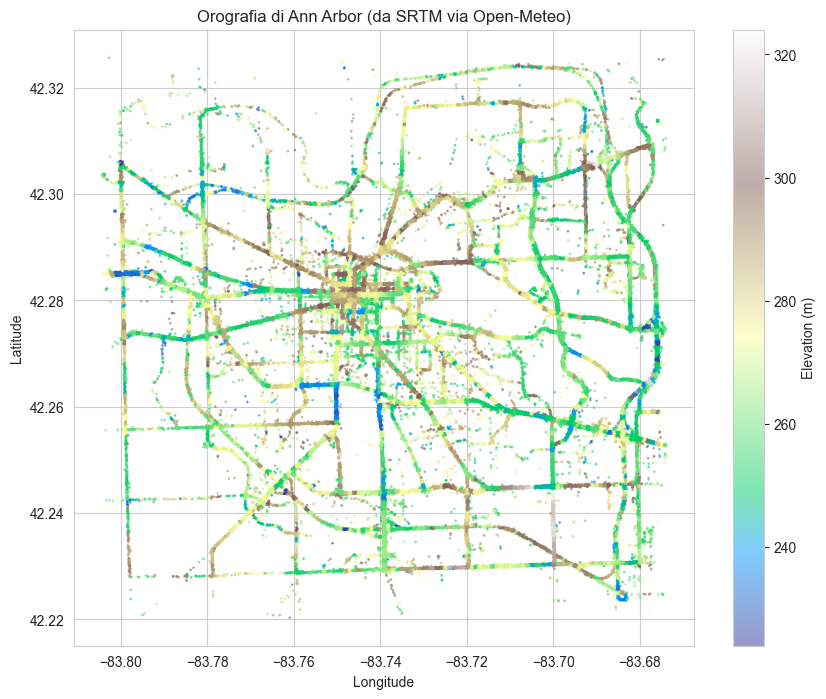

In [11]:
df = df.merge(elev_df, on=['lat_round', 'lon_round'], how='left')
print(f"Dataset ora ha {df['elevation_m'].notna().sum():,} righe con elevation ({df['elevation_m'].notna().mean()*100:.2f}%)")

# Visualizziamo l'orografia di Ann Arbor
sample = df.sample(n=100_000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(sample['Longitude_deg'], sample['Latitude_deg'],
                c=sample['elevation_m'], cmap='terrain', s=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Elevation (m)')
ax.set_title('Orografia di Ann Arbor (da SRTM via Open-Meteo)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## 7. Calcolo della pendenza (slope)

La pendenza istantanea sotto un veicolo si ottiene come:

$$\text{slope} = \frac{\Delta \text{elevation}}{\Delta \text{distance}}$$

Calcoliamo $\Delta$ tra righe consecutive **all'interno dello stesso trip** (raggruppando per `VehId` + `Trip`).

Per la distanza usiamo la **formula di Haversine** che calcola distanze su sfera dati lat/lon.

In [12]:
def haversine_vec(lat1, lon1, lat2, lon2):
    """Distanza in metri tra coppie di coordinate (vettoriale)."""
    R = 6371000.0  # raggio Terra in metri
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Ordina per trip + timestamp
df = df.sort_values(['VehId', 'Trip', 'Timestampms']).reset_index(drop=True)

# Calcola shift all'interno del trip
grp = df.groupby(['VehId', 'Trip'])
df['lat_prev'] = grp['Latitude_deg'].shift(1)
df['lon_prev'] = grp['Longitude_deg'].shift(1)
df['elev_prev'] = grp['elevation_m'].shift(1)
df['ts_prev'] = grp['Timestampms'].shift(1)

# Distanza in metri tra punti consecutivi (NaN per la prima riga di ogni trip)
df['dist_m'] = haversine_vec(df['lat_prev'], df['lon_prev'],
                              df['Latitude_deg'], df['Longitude_deg'])
df['dz_m'] = df['elevation_m'] - df['elev_prev']
df['dt_ms'] = df['Timestampms'] - df['ts_prev']

# Slope = dz / distance (radianti circa, per piccoli angoli ≈ pendenza in %)
# Evitiamo division by zero con dist > 1m
df['slope'] = np.where(df['dist_m'] > 1.0, df['dz_m'] / df['dist_m'], 0.0)

# Clip outlier (SRTM ha risoluzione 30m, slope > 30% in città è errore)
df['slope'] = df['slope'].clip(-0.3, 0.3)

# Cleanup colonne intermedie
df = df.drop(columns=['lat_prev', 'lon_prev', 'elev_prev', 'ts_prev'])

print("Statistiche slope (frazione, es. 0.05 = 5%):")
print(df['slope'].describe())
print(f"\nSlope NaN: {df['slope'].isna().sum():,} (prime righe di ogni trip)")

Statistiche slope (frazione, es. 0.05 = 5%):
count    1.792287e+07
mean     7.662844e-06
std      5.585678e-02
min     -3.000000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.000000e-01
Name: slope, dtype: float64

Slope NaN: 0 (prime righe di ogni trip)


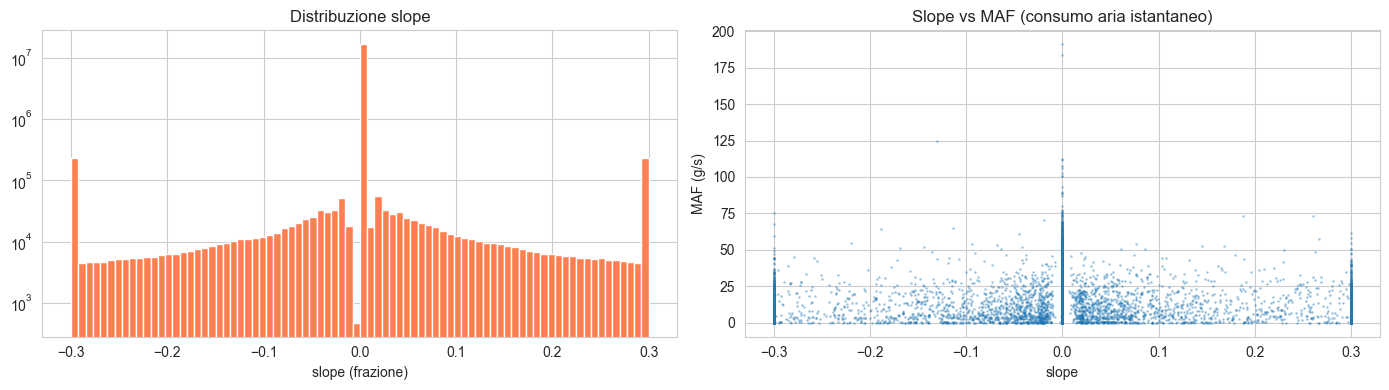

In [13]:
# Visualizza la distribuzione della pendenza
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['slope'].dropna().hist(bins=80, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Distribuzione slope')
axes[0].set_xlabel('slope (frazione)')
axes[0].set_yscale('log')

# Slope in funzione di MAF (ci aspettiamo correlazione: in salita → più consumo)
sample = df.sample(n=50_000, random_state=42).dropna(subset=['slope', 'MAF_g_per_sec'])
axes[1].scatter(sample['slope'], sample['MAF_g_per_sec'], s=1, alpha=0.3)
axes[1].set_xlabel('slope')
axes[1].set_ylabel('MAF (g/s)')
axes[1].set_title('Slope vs MAF (consumo aria istantaneo)')
plt.tight_layout()
plt.show()

## 8. Feature time-derived: accelerazione

Calcoliamo l'accelerazione come derivata della velocità rispetto al tempo. Attenzione al **sampling rate irregolare** (delta tempo varia tra 100ms e 1400ms): non possiamo usare semplici diff(), dobbiamo dividere per il delta-tempo reale.

In [14]:
grp = df.groupby(['VehId', 'Trip'])
df['speed_prev'] = grp['Vehicle_Speed_km_per_h'].shift(1)
df['dv_kmh'] = df['Vehicle_Speed_km_per_h'] - df['speed_prev']

# Accelerazione in km/h per secondo. Evitiamo div by zero con dt > 50ms
df['accel_kmh_s'] = np.where(df['dt_ms'] > 50, df['dv_kmh'] / (df['dt_ms'] / 1000.0), 0.0)

# Clip valori implausibili (accelerazioni civili: -15 a +10 km/h al sec)
df['accel_kmh_s'] = df['accel_kmh_s'].clip(-15, 10)

df = df.drop(columns=['speed_prev', 'dv_kmh'])

print(df['accel_kmh_s'].describe())

count    1.792287e+07
mean    -1.018694e-01
std      3.917571e+00
min     -1.500000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+01
Name: accel_kmh_s, dtype: float64


## 9. Salvataggio del dataset enriched

Salviamo il parquet finale che i notebook successivi caricheranno. Manteniamo solo le colonne utili per ridurre il file.

In [15]:
cols_keep = [
    'VehId', 'Trip', 'Timestampms', 'Datetime',
    'Latitude_deg', 'Longitude_deg', 'elevation_m', 'slope',
    'Vehicle_Speed_km_per_h', 'accel_kmh_s',
    'Engine_RPM_RPM', 'Absolute_Load_pct',
    'MAF_g_per_sec', 'log_MAF',
    'OAT_DegC',
    'Short_Term_Fuel_Trim_Bank_1_pct', 'Long_Term_Fuel_Trim_Bank_1_pct',
    'EngineType', 'Generalized_Weight',
    'dist_m', 'dt_ms'
]

df_final = df[cols_keep].copy()

# Rimuovi righe con NaN su slope/accel (le prime di ogni trip)
df_final = df_final.dropna(subset=['slope', 'accel_kmh_s', 'elevation_m']).reset_index(drop=True)

OUT_PATH = OUTPUT_DIR / "ved_enriched.parquet"
df_final.to_parquet(OUT_PATH, compression='snappy', index=False)

print(f"✓ Salvato: {OUT_PATH}")
print(f"  Righe finali: {len(df_final):,}")
print(f"  Dimensione su disco: {OUT_PATH.stat().st_size / 1e6:.1f} MB")
print(f"  Trip unici: {df_final.groupby(['VehId','Trip']).ngroups:,}")
print(f"  Veicoli unici: {df_final['VehId'].nunique()}")

✓ Salvato: outputs\ved_enriched.parquet
  Righe finali: 17,922,869
  Dimensione su disco: 378.1 MB
  Trip unici: 26,285
  Veicoli unici: 299


## 10. Verifica finale e statistiche di sanity

Un ultimo check rapido sulle feature derivate, e una visualizzazione di un trip esemplare per assicurarci che slope e accelerazione siano sensati.

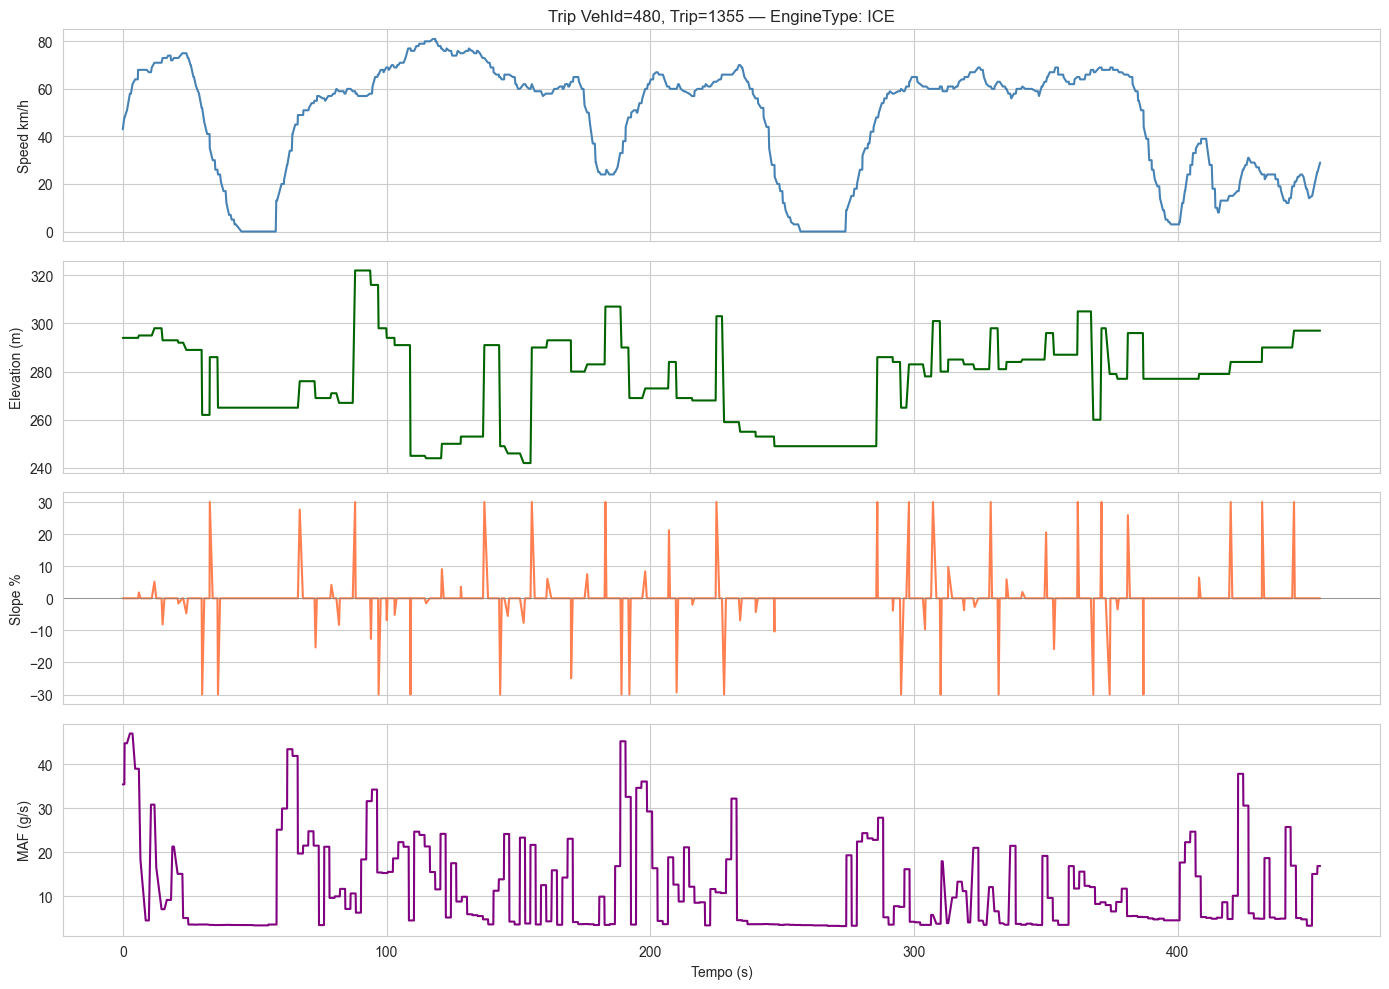

In [16]:
# Prendi un trip random sufficientemente lungo
trip_lens = df_final.groupby(['VehId', 'Trip']).size().reset_index(name='n')
trip_lens = trip_lens[trip_lens['n'].between(500, 2000)]
veh_id, trip_id, _ = trip_lens.sample(n=1, random_state=42).iloc[0]

trip = df_final[(df_final['VehId']==veh_id) & (df_final['Trip']==trip_id)].sort_values('Timestampms')
trip['elapsed_s'] = (trip['Timestampms'] - trip['Timestampms'].iloc[0]) / 1000

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(trip['elapsed_s'], trip['Vehicle_Speed_km_per_h'], color='steelblue')
axes[0].set_ylabel('Speed km/h')
axes[0].set_title(f'Trip VehId={veh_id}, Trip={trip_id} — EngineType: {trip["EngineType"].iloc[0]}')

axes[1].plot(trip['elapsed_s'], trip['elevation_m'], color='darkgreen')
axes[1].set_ylabel('Elevation (m)')

axes[2].plot(trip['elapsed_s'], trip['slope']*100, color='coral')
axes[2].set_ylabel('Slope %')
axes[2].axhline(0, color='gray', lw=0.5)

axes[3].plot(trip['elapsed_s'], trip['MAF_g_per_sec'], color='purple')
axes[3].set_ylabel('MAF (g/s)')
axes[3].set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()

---

## Riepilogo

**Cosa abbiamo costruito:**
- Dataset VED consolidato da tutti i parquet in `content/`
- Filtraggio outlier (Absolute_Load > 200%, RPM > 8000, Speed > 200, MAF > 300)
- Arricchimento con elevation via Open-Meteo (gratuito, ~150 chiamate batch grazie a dedup)
- Calcolo pendenza (slope) via Haversine + derivata elevation/distance
- Calcolo accelerazione gestendo il sampling irregolare

**Output:** `outputs/ved_enriched.parquet` — pronto per i notebook 2 e 3.

**Prossimi passi:**
- Notebook 2 → modello supervised per predire MAF (cruise control adattivo predittivo)
- Notebook 3 → clustering unsupervised per caratterizzare tratti stradali